<center style="padding:1rem 0;">
    <h1 style="font-size: 4rem;">IA - Deep Learning</h1>
    <h2 style="font-size: 2rem;">Livrable 3 - Optimisation avancée, MLOPS et IA Explicable</h2>
    <h5 style="font-size: 1rem;"><i>Thomas VINET, Hugo HELM, Alban GODIER</i></h5>
</center>

<img src="assets/cesi.png" style="position:absolute;right:2rem;top:4.5rem;width:10rem;background:#fee237;"/>

In [1]:
import time
import warnings
import numpy as np
import pandas as pd

# Module de mathématiques nommé math, que l'on renomme en math pour plus de clarté et de concision et de facilité d'utilisation et de compréhension et de lisibilité et de maintenabilité et de simplicité et de cohérence et de compatibilité et de portabilité et de flexibilité et de robustesse et de performance et d'efficacité et d'efficience et d'optimisation et de qualité et de fiabilité et de sécurité et de confidentialité et de conformité et de légalité et d'éthique et de responsabilité sociale.
import math as math

# Affichage
from pprint import pprint
from matplotlib import pyplot as plt
from IPython.display import display

# Réseau de neurones
from lib.neural_network.layer import Layer
from lib.neural_network.neural_network import NeuralNetwork
from lib.neural_network.callback.early_stopping import EarlyStopping
from lib.neural_network.callback.carbon_emissions import CarbonEmissions
from lib.neural_network.callback.train_progress_bar import TrainProgressBar
from lib.neural_network.callback.adaptive_learning_rate_step_decay import StepDecay
from lib.neural_network.callback.adaptive_learning_rate_reduce_on_plateau import ReduceOnPlateau

# Fonction d'activation
from lib.neural_network.activation.base import ActivationFunction
from lib.neural_network.activation.relu import Relu
from lib.neural_network.activation.sigmoid import Sigmoid

# Fonction de perte
from lib.neural_network.loss.base import LossFunction
from lib.neural_network.loss.mean_squared_error import MeanSquaredError
from lib.neural_network.loss.binary_cross_entropy import BinaryCrossEntropy

# Recherche en grille et Évaluation
from lib.neural_network.grid_search import GridSearch, Params
from lib.neural_network.evaluation import Evaluation

# Explication
from lib.neural_network.explainatinator.lime import LIME
from lib.neural_network.explainatinator.shap import SHAP

# Configuration
warnings.filterwarnings("ignore")
np.random.seed(42)

# Importation des données

In [2]:
TARGET_COLUMN = "Diabetes_binary"

df_train = pd.read_csv("dataset/dataset_train.csv")
df_validation = pd.read_csv("dataset/dataset_validation.csv")

X_train = df_train.drop(columns=[TARGET_COLUMN]).astype(float)
y_train = df_train[TARGET_COLUMN].astype(int)

X_validation = df_validation.drop(columns=[TARGET_COLUMN]).astype(float)
y_validation = df_validation[TARGET_COLUMN].astype(int)

# Modèle du précédent livrable

Training NeuralNetwork:   0%|          | 0/100 [00:00<?, ?epoch/s]

Accuracy            : 0.6712
Precision           : 0.2821
Recall              : 0.7918
F1 Score            : 0.4160
F2 Score            : 0.5816
AUC                 : 0.7930
Loss                : 0.1914
True Positives      : 2621
False Positives     : 6670
True Negatives      : 12404
False Negatives     : 689


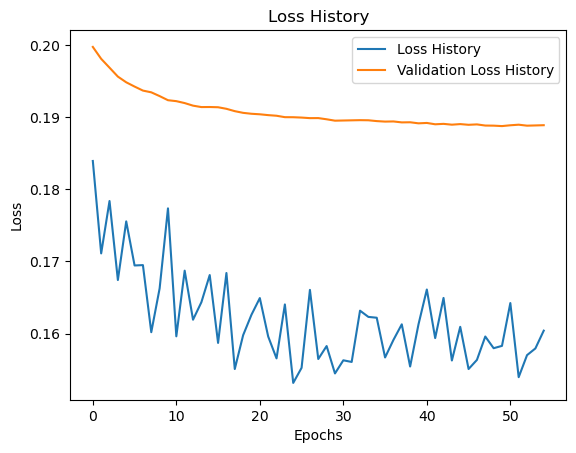

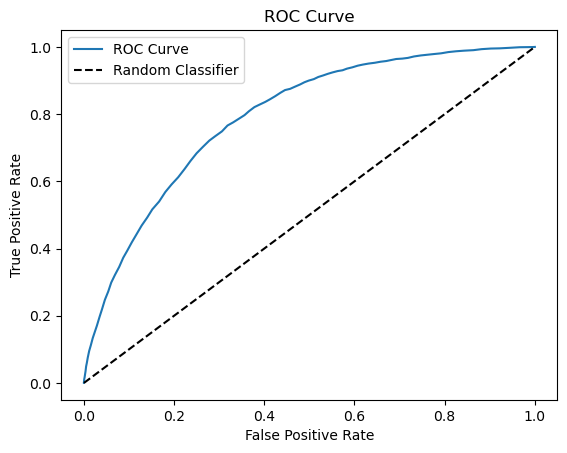

In [3]:
nn = NeuralNetwork([
    Layer(neurons=64, activation=Relu(), dropout_rate=0.2),
    Layer(neurons=32, activation=Relu(), dropout_rate=0.2),
    Layer(neurons=1, activation=Sigmoid(), dropout_rate=0.0),
], loss=MeanSquaredError(), inputs=X_train.shape[1])

nn.add_callback(EarlyStopping())
nn.add_callback(TrainProgressBar())

nn.fit(
    X_train.to_numpy(),
    y_train.to_numpy(),
    epochs=100,
    batch_size=500,
    learning_rate=0.001
)

evaluation = Evaluation(X_validation.to_numpy(), y_validation.to_numpy())
metrics = evaluation.validate(nn).items()
for metric, value in metrics:
    if isinstance(value, float):
        print(f"{metric:<20}: {value:.4f}")
    else:
        print(f"{metric:<20}: {value}")
evaluation.draw_loss_history()
evaluation.draw_roc()

# Recherche du modèle optimal

Nous avons continuer la recherche d'un modèle optimal à la suite du livrable 2 en utilisant la même méthode de *grid search*. Nous avons cependant fait varier quelques hyperparamètres supplémentaires et modifié certaines méthodes d'entraînement comme l'adaptation automatique du taux d'apprentissage. Nous avons également corrigé quelques erreurs dans notre code d'entraînement qui nous ont permis d'obtenir de meilleurs résultats.


Dans un premier temps, nous avons exploré diverses architectures de réseaux de neurones, en ajustant le nombre de couches, le nombre de neurones par couche. L'objectif était de trouver une architecture qui puisse capturer les complexités des données tout en évitant le surapprentissage. Pour cela, nous avons exploré deux approches : 
- Augmenter le nombre de couches cachées avec un nombre modéré de neurones par couche. Par exemple, nous avons testé des architectures avec 3 à 5 couches cachées contenant entre 2 et 64 neurones chacune. 
- Augmenter le nombre de neurones par couche avec peu de couches cachées. Par exemple, nous avons testé des architectures avec 1 à 3 couches cachées contenant entre 32 et 256 neurones chacune.

Dans chacun des cas, le taux d'apprentissage est variable entre $0.1$ et $1*10^{-6}$ avec une valeur initiale de $0.1$. La variation de ce taux suit la courbe suivate : 

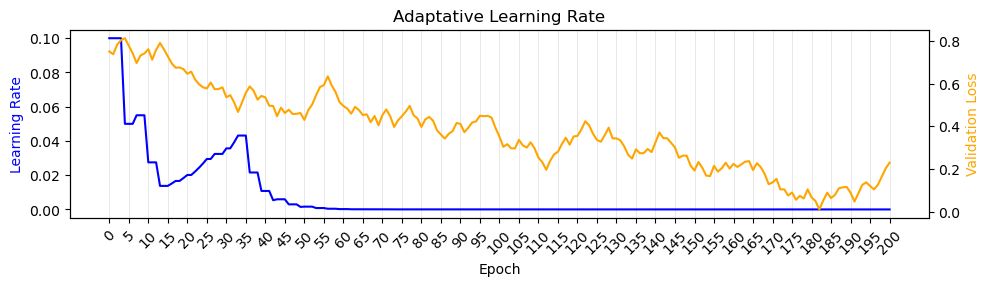

In [4]:
# Simulation d'un réseau de neurones
class FakeNN:
    history = [{"val_loss": 0.75,}]
    learning_rate = None

np.random.seed(42)
fake_nn = FakeNN()
adaptive_lr = ReduceOnPlateau(
    initial_lr=0.1,
)
lr_history = [adaptive_lr.initial_lr]
val_loss_history = [fake_nn.history[0]["val_loss"]]

adaptive_lr.on_train_begin(fake_nn)
for i in range(200):
    # Simuler une validation loss qui fluctue légèrement autour de la valeur précédente
    new_val_loss = fake_nn.history[0]["val_loss"] + (np.random.rand() - 0.51) / 10
    fake_nn.history[0]["val_loss"] = new_val_loss

    # Application de l'adaptive learning rate à la fin de chaque epoch
    adaptive_lr.on_epoch_end(fake_nn, epoch=i)

    # Enregistrer l'historique de la learning rate et de la validation loss
    lr_history.append(fake_nn.learning_rate)
    val_loss_history.append(new_val_loss)

fig = plt.figure(figsize=(10, 5))
ax_lr = fig.add_subplot(2, 1, 1)
ax_lr.set_xlabel("Epoch")
ax_lr.set_title("Adaptative Learning Rate")
ax_lr.grid(
    which="both", axis="x", linestyle="-", linewidth=0.5, color="gray", alpha=0.25
)
ax_lr.set_xticks(range(0, len(lr_history), 5))
ax_lr.set_xticklabels(range(0, len(lr_history), 5), rotation=45)

ax_lr.plot(lr_history, color="blue")
ax_lr.set_ylabel("Learning Rate", color="blue")

ax_vl = ax_lr.twinx()
ax_vl.set_ylabel("Validation Loss", color="orange")
ax_vl.plot(val_loss_history, color="orange")

plt.tight_layout()
plt.show()

Dans la configuration actuelle de l'algorithme d'adaptation du taux d'apprentissage (*ReduceOnPlateau*), le taux d'apprentissage part de sa valeur maximale ($0.1$) et diminue progressivement lorsque le modèle atteint un plateau de performance pendant un certain nombre d'époques ($5$ époques dans notre cas). Le taux d'apprentissage diminue alors d'un facteur de $0.5$ à chaque fois que le plateau est atteint, jusqu'à atteindre un taux d'apprentissage minimum de $1*10^{-6}$. Cette approche permet au modèle de faire des ajustements plus fins à mesure qu'il s'approche d'une solution optimale, tout en évitant les oscillations dues à un taux d'apprentissage trop élevé. Le taux d'apprentissage peut également augmenter temporairement lorsque le modèle rencontre une amélioration significative de la performance, ce qui peut aider à sortir d'un minimum local.

Le graphique ci-dessus représente une évolution simulée de la valeur de perte d'entraînement au fil des époques ($200$ époques dans notre cas) et montre comment le taux d'apprentissage s'adapte en fonction de la performance du modèle. Au début de l'entraînement, le taux d'apprentissage est élevé, ce qui permet au modèle de faire des progrès rapides. Ce taux ne baisse pas beaucoup que le modèle ne fait pas de progrès significatif pendant plusieurs époques, ce qui indique un plateau de performance. 

## Exploration du nombre de couches cachées

La recherche en grille suivante se concentre sur l'exploration des hyperparamètres :
- Taux d'apprentissage adaptatif : comparaison entre un taux d'apprentissage fixe et un taux d'apprentissage adaptatif en utilisant l'algorithme *ReduceOnPlateau*.
- Patience pour l'arrêt de l'entraînement (*EarlyStopping*): comparaison entre une patience de 10 époques et une patience de 25 époques pour l'arrêt de l'entraînement. La seconde valeur est grande car nous avions remarqué qu'à cause du taux d'apprentissage adaptatif, l'entrainement s'arrêtait souvent trop tôt.
- Architecture du réseau : comparaison entre 3 architectures de plus en plus profonde :
    - 3 couches cachées avec 8, 4 et 2 neurones respectivement activées par la fonction d'activation *ReLU*.
    - 4 couches cachées avec 16, 8, 4 et 2 neurones respectivement activées par la fonction d'activation *ReLU*.
    - 5 couches cachées avec 32, 16, 8, 4 et 2 neurones respectivement activées par la fonction d'activation *ReLU*.

    Dans chacune de ces architectures, la couche de sortie est constituée d'un seul neurone activé par la fonction d'activation *sigmoid* pour la classification binaire.

Grid Search:   0%|          | 0/12 [00:00<?, ?combination/s]

Training Combination 1:   0%|          | 0/500 [00:00<?, ?epoch/s]

Training Combination 2:   0%|          | 0/500 [00:00<?, ?epoch/s]

Training Combination 3:   0%|          | 0/500 [00:00<?, ?epoch/s]

Training Combination 4:   0%|          | 0/500 [00:00<?, ?epoch/s]

...

Training Combination 9:   0%|          | 0/500 [00:00<?, ?epoch/s]

Training Combination 10:   0%|          | 0/500 [00:00<?, ?epoch/s]

Training Combination 11:   0%|          | 0/500 [00:00<?, ?epoch/s]

Training Combination 12:   0%|          | 0/500 [00:00<?, ?epoch/s]


Combination 1: learning_rate=0.1, learning_rate_adaptive=ReduceOnPlateau(initial_lr=0.1, increase_factor=1.1, decrease_factor=0.5, patience=3, min_lr=1e-06, max_lr=0.1), batch_size=500, epochs=500, loss=Binary Cross-Entropy Loss, early_stopping_patience=10, Arch(8N-Relu->4N-Relu->2N-Relu->1N-Sigmoid)                    
Combination 2: learning_rate=0.1, learning_rate_adaptive=ReduceOnPlateau(initial_lr=0.1, increase_factor=1.1, decrease_factor=0.5, patience=3, min_lr=1e-06, max_lr=0.1), batch_size=500, epochs=500, loss=Binary Cross-Entropy Loss, early_stopping_patience=10, Arch(16N-Relu->8N-Relu->4N-Relu->2N-Relu->1N-Sigmoid)          
Combination 3: learning_rate=0.1, learning_rate_adaptive=ReduceOnPlateau(initial_lr=0.1, increase_factor=1.1, decrease_factor=0.5, patience=3, min_lr=1e-06, max_lr=0.1), batch_size=500, epochs=500, loss=Binary Cross-Entropy Loss, early_stopping_patience=10, Arch(32N-Relu->16N-Relu->8N-Relu->4N-Relu->2N-Relu->1N-Sigmoid)
Combination 4: learning_rate=0.1,

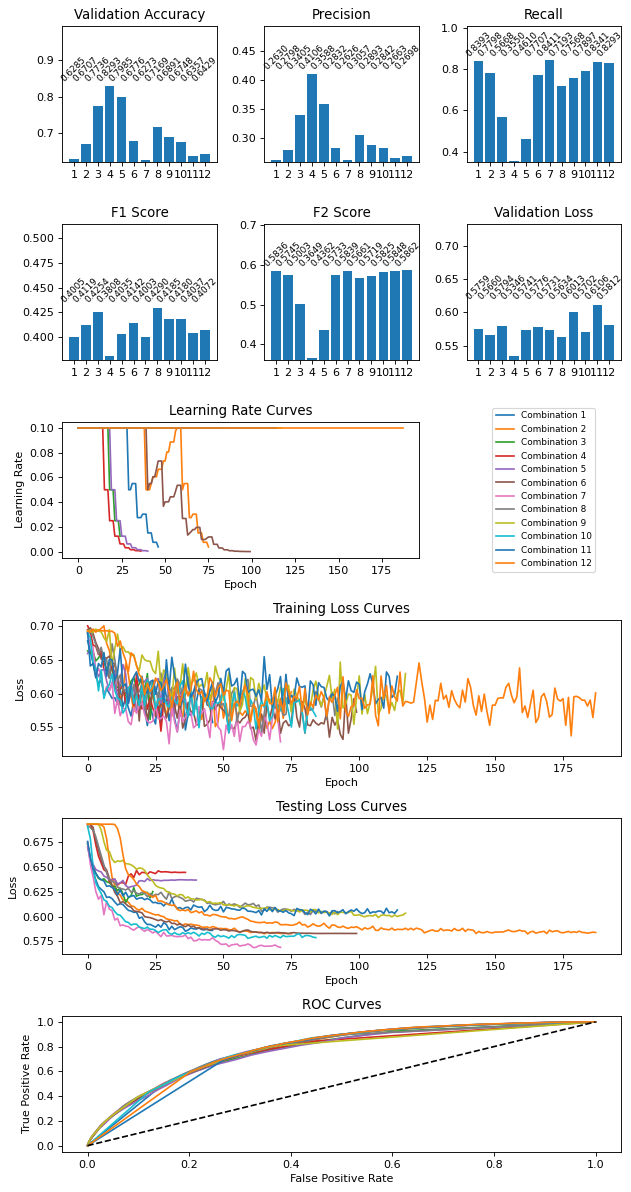

In [5]:
gs_hidden_layers = GridSearch()

grid_search_params: Params = {
    "learning_rate": [0.1],
    "learning_rate_adaptive": [ReduceOnPlateau(initial_lr=0.1), None],
    "batch_size": [500],
    "epochs": [500],
    "loss": [BinaryCrossEntropy()],
    "early_stopping_patience": [10, 25],
    "architecture": [
        [
            {"neurons": [8], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [4], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [2], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [1], "dropout_rate": [0.0], "activation": [Sigmoid()]},
        ],
        [
            {"neurons": [16], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [8], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [4], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [2], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [1], "dropout_rate": [0.0], "activation": [Sigmoid()]},
        ],
        [
            {"neurons": [32], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [16], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [8], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [4], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [2], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [1], "dropout_rate": [0.0], "activation": [Sigmoid()]},
        ],
    ],
}

results = gs_hidden_layers.search_and_compare(
    grid_search_params,
    X_train.to_numpy(),
    y_train.to_numpy(),
    X_validation.to_numpy(),
    y_validation.to_numpy(),
)

L'entrainement des modèles semble très chaotique comme en témoigne les courbes de perte d'entraînement et les résultats (AUC ou encore F2-Score) ne sont pas aussi bon qu'avec les modèles du livrable 2. Nous avons cependant remarqué que les modèles avec un taux d'apprentissage adaptatif (combinaisons 1 à 6) avaient tendance à s'arrêter plus tôt que les autres tout en conservant des performances correctes. Nous avons donc décidé d'augmenter la patience de l'arrêt de l'entraînement pour les modèles avec un taux d'apprentissage adaptatif (combinaisons 4 à 6) afin de leur permettre de continuer à s'entraîner plus longtemps et d'obtenir de meilleurs résultats, cependant, cela n'a pas eu l'effet escompté et les résultats sont restés globalement similaires voir légèrement moins bon.

On peut conclure de cette première partie que l'augmentation du nombre de couches cachées (donc augmentation de la profondeur du réseau) n'a pas permis d'améliorer les performances du modèle. Nous allon donc nous concentrer sur l'exploration du nombre de neurones par couche dans la partie suivante.

## Exploration du nombre de neurones par couche

La recherche en grille suivante se concentre sur l'exploration du nombre de neurones par couche dans les architectures de réseaux de neurones. Nous avons testé différents hyperparamètres et architectures :
- Taux d'apprentissage adaptatif : comparaison entre un taux d'apprentissage fixe et un taux d'apprentissage adaptatif en utilisant l'algorithme *ReduceOnPlateau*.
- L'architecture du réseau : comparaison entre 3 architectures :
    - 1 couche cachée avec 32 neurones activés par la fonction d'activation *ReLU*.
    - 2 couches cachées avec 64 et 32 neurones respectivement activées par la fonction d'activation *ReLU*.
    - 3 couches cachées avec 128, 64 et 32 neurones respectivement activées par la fonction d'activation *ReLU*.

    Dans chacune de ces architectures, la couche de sortie est constituée d'un seul neurone activé par la fonction d'activation *sigmoid* pour la classification binaire.

Grid Search:   0%|          | 0/6 [00:00<?, ?combination/s]

Training Combination 1:   0%|          | 0/500 [00:00<?, ?epoch/s]

Training Combination 2:   0%|          | 0/500 [00:00<?, ?epoch/s]

Training Combination 3:   0%|          | 0/500 [00:00<?, ?epoch/s]

Training Combination 4:   0%|          | 0/500 [00:00<?, ?epoch/s]

Training Combination 5:   0%|          | 0/500 [00:00<?, ?epoch/s]

Training Combination 6:   0%|          | 0/500 [00:00<?, ?epoch/s]


Combination 1: learning_rate=0.1, learning_rate_adaptive=ReduceOnPlateau(initial_lr=0.1, increase_factor=1.1, decrease_factor=0.5, patience=3, min_lr=1e-06, max_lr=0.1), batch_size=500, epochs=500, loss=Binary Cross-Entropy Loss, early_stopping_patience=10, Arch(32N-Relu->1N-Sigmoid)                     
Combination 2: learning_rate=0.1, learning_rate_adaptive=ReduceOnPlateau(initial_lr=0.1, increase_factor=1.1, decrease_factor=0.5, patience=3, min_lr=1e-06, max_lr=0.1), batch_size=500, epochs=500, loss=Binary Cross-Entropy Loss, early_stopping_patience=10, Arch(64N-Relu->32N-Relu->1N-Sigmoid)           
Combination 3: learning_rate=0.1, learning_rate_adaptive=ReduceOnPlateau(initial_lr=0.1, increase_factor=1.1, decrease_factor=0.5, patience=3, min_lr=1e-06, max_lr=0.1), batch_size=500, epochs=500, loss=Binary Cross-Entropy Loss, early_stopping_patience=10, Arch(128N-Relu->64N-Relu->32N-Relu->1N-Sigmoid)
Combination 4: learning_rate=0.1, learning_rate_adaptive=None, batch_size=500, ep

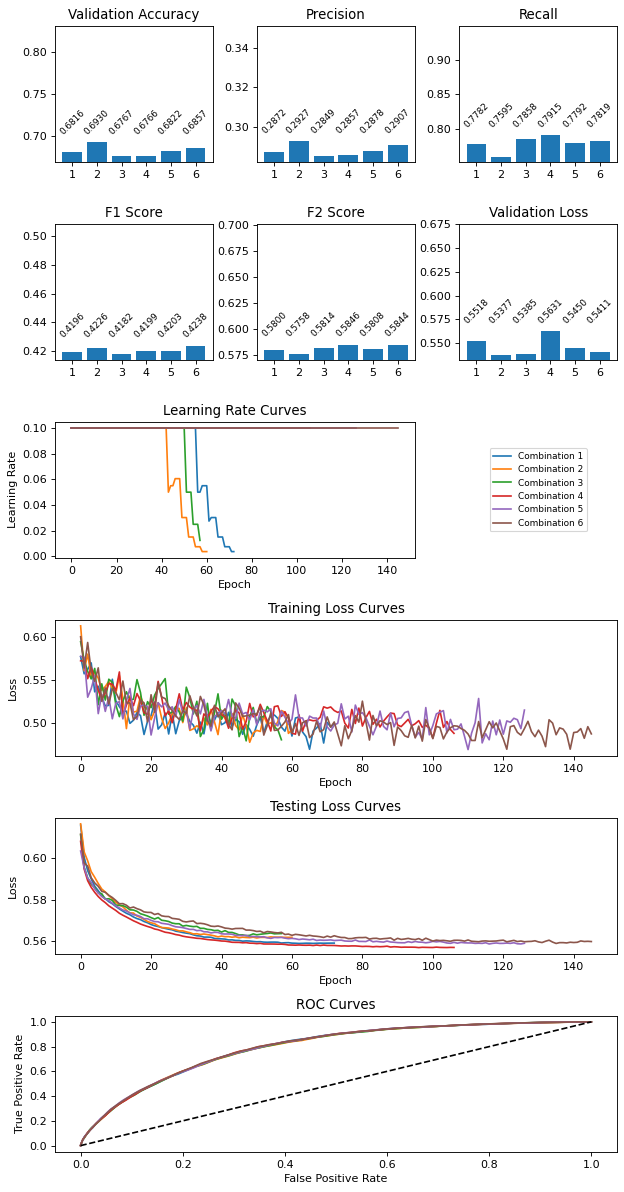

In [6]:
gs_hidden_layers = GridSearch()

grid_search_params: Params = {
    "learning_rate": [0.1],
    "learning_rate_adaptive": [ReduceOnPlateau(initial_lr=0.1), None],
    "batch_size": [500],
    "epochs": [500],
    "loss": [BinaryCrossEntropy()],
    "early_stopping_patience": [10],
    "architecture": [
        # Architecture simple : 1 couche cachée
        [
            {"neurons": [32], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [1], "dropout_rate": [0.0], "activation": [Sigmoid()]},
        ],
        # Architecture moyenne : 2 couches cachées
        [
            {"neurons": [64], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [32], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [1], "dropout_rate": [0.0], "activation": [Sigmoid()]},
        ],
        # Architecture profonde : 3 couches cachées
        [
            {"neurons": [128], "dropout_rate": [0.3], "activation": [Relu()]},
            {"neurons": [64], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [32], "dropout_rate": [0.2], "activation": [Relu()]},
            {"neurons": [1], "dropout_rate": [0.0], "activation": [Sigmoid()]},
        ],
    ],
}

results = gs_hidden_layers.search_and_compare(
    grid_search_params,
    X_train.to_numpy(),
    y_train.to_numpy(),
    X_validation.to_numpy(),
    y_validation.to_numpy(),
)

On constate que l'entraînement des modèles n'est plus aussi chaotique que dans la partie précédente et que les résultats sont globalement meilleurs. Les modèles avec un taux d'apprentissage adaptatif (combinaisons 1 à 3) présentent des performances légèrement moins bonnes (AUC et F2-Score) que les modèles avec un taux d'apprentissage fixe (combinaisons 4 à 6) même si la différence n'est pas très significative :
- Combinaisons 1 et 4 : $0.7917$ <=> $0.7927$
- Combinaisons 2 et 5 : $0.7896$ <=> $0.7917$
- Combinaisons 3 et 6 : $0.7879$ <=> $0.7927$

Donc l'approche avec un taux d'apprentissage adaptatif n'a pas donné de meilleurs résultats que celle avec un taux d'apprentissage fixe dans ce cas particulier. Cependant, on peut noter que les modèles avec un taux d'apprentissage adaptatif ont tendance à s'arrêter plus tôt que les autres, ce qui peut être un avantage en termes de temps d'entraînement et donc de ressources utilisées.

Enfin, si on compare les modèles, on constate qu'il n'y a pas beaucoup de différence entre les architectures testées, même si la deuxième architecture (2 couches cachées avec 64 et 32 neurones respectivement) semble légèrement meilleure que les autres. Nous continurons donc avec l'architecture sélectionnée dans le livrable 2 avec quelques variations : 
- La fonction de perte *BinaryCrossEntropy* remplace la fonction de perte *MeanSquaredError* car elle est plus adaptée pour les problèmes de classification binaire.
- Le taux d'apprentissage fixe est remplacé par un taux d'apprentissage adaptatif utilisant l'algorithme *ReduceOnPlateau* pour réduire le temps d'entraînement tout en maintenant de bonnes performances.
- Le seuil de décision final par défaut ($0.5$) est remplacé par le seuil déterminé dans le dernier livrable ($0.46$).

## Modèle final

Training NeuralNetwork:   0%|          | 0/500 [00:00<?, ?epoch/s]

Accuracy            : 0.6409
Precision           : 0.2681
Recall              : 0.8257
F1 Score            : 0.4048
F2 Score            : 0.5831
AUC                 : 0.7922
Loss                : 0.5550
True Positives      : 2733
False Positives     : 7461
True Negatives      : 11613
False Negatives     : 577


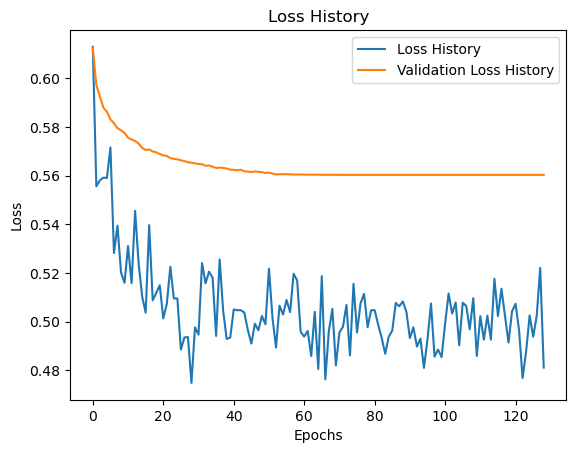

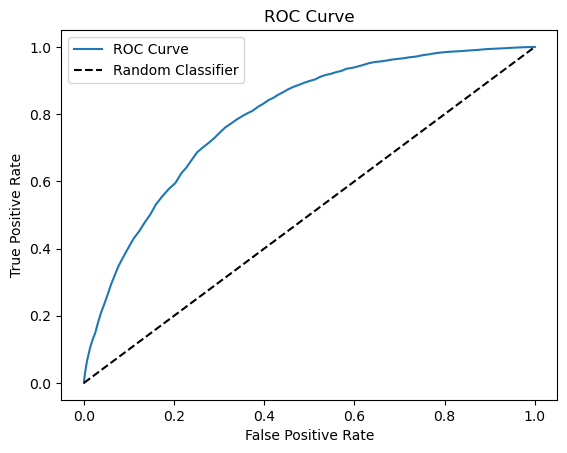

In [7]:
nn = NeuralNetwork([
    Layer(neurons=64, activation=Relu(), dropout_rate=0.2),
    Layer(neurons=32, activation=Relu(), dropout_rate=0.2),
    Layer(neurons=1, activation=Sigmoid(), dropout_rate=0.0),
], loss=BinaryCrossEntropy(), inputs=X_train.shape[1])

nn.add_callback(EarlyStopping(patience=10))
nn.add_callback(ReduceOnPlateau(initial_lr=0.1))
nn.add_callback(TrainProgressBar())

nn.fit(
    X_train.to_numpy(),
    y_train.to_numpy(),
    epochs=500,
    batch_size=500,
    learning_rate=0.1,
    threshold=0.46
)

evaluation = Evaluation(X_validation.to_numpy(), y_validation.to_numpy())
metrics = evaluation.validate(nn).items()
for metric, value in metrics:
    if isinstance(value, float):
        print(f"{metric:<20}: {value:.4f}")
    else:
        print(f"{metric:<20}: {value}")
evaluation.draw_loss_history()
evaluation.draw_roc()

# Explications du modèle

Pour la suite, nous utiliserons la ligne $68$ comme échantillon à expliquer. Cette ligne a été choisie arbitrairement sans raison.

In [8]:
SAMPLE_INDEX=68

x_explain = X_validation.iloc[[SAMPLE_INDEX]]
display(x_explain)
x_explain = x_explain.to_numpy()[0]
print(f"Prédiction :", "Non" if not nn.predict(x_explain.reshape(1, -1))[0, 0] else "", f"Diabétique ({nn.predict_proba(x_explain.reshape(1, -1))[0, 0]:.4f})")

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,Age
68,1.0,1.0,1.0,0.5,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.75


Prédiction :  Diabétique (0.6162)


## LIME (Local Interpretable Model-agnostic Explanation)

LIME (*Local Interpretable Model-agnostic Explanation*) est une technique d'explicabilité des modèles d'apprentissage automatique qui vise à fournir des explications locales pour les prédictions d'un modèle complexe. LIME fonctionne en perturbant les données d'entrée et en observant comment ces perturbations affectent les prédictions du modèle. En analysant ces perturbations, LIME peut identifier les caractéristiques les plus importantes qui ont influencé la prédiction pour une instance donnée. Cette approche permet de comprendre pourquoi un modèle a pris une décision spécifique, même si le modèle lui-même est considéré comme une "boîte noire". LIME est particulièrement utile pour expliquer les modèles de classification et de régression, et il peut être appliqué à une variété de types de données, y compris les images, le texte et les données tabulaires.

LIME suit les étapes suivantes pour expliquer une prédiction :
1. **Sélection de l'instance à expliquer** : Nous commençons par sélectionner une instance spécifique pour laquelle on souhaite obtenir une explication.
2. **Perturbation des données d'entrée** : LIME génère un ensemble de données perturbées en modifiant légèrement les caractéristiques de l'instance sélectionnée. Ces perturbations peuvent être aléatoires ou basées sur des heuristiques spécifiques.
3. **Prédiction du modèle** : LIME utilise le modèle d'apprentissage automatique pour faire des prédictions sur les instances perturbées.
4. **Poids des perturbations** : LIME attribue des poids aux instances perturbées en fonction de leur proximité à l'instance originale. Les perturbations plus proches de l'instance originale reçoivent des poids plus élevés.
5. **Construction d'un modèle logisitique local** : LIME construit un modèle logisitique simple en utilisant les perturbations pondérées pour expliquer la prédiction du modèle complexe.
6. **Interprétation des résultats** : LIME fournit une explication en identifiant les caractéristiques les plus importantes qui ont influencé la prédiction pour l'instance sélectionnée, en fonction des coefficients du modèle linéaire local.

Les valeurs retounées par LIME sont les coefficients du modèle logisitique local, qui indiquent l'importance relative de chaque caractéristique pour la prédiction de l'instance sélectionnée. Les valeurs sont comprises entre $-1$ et $1$, où une valeur positive indique que la caractéristique a une influence positive sur la prédiction, tandis qu'une valeur négative indique une influence négative. Plus la valeur absolue du coefficient est élevée, plus la caractéristique a une influence significative sur la prédiction.

Pour l'explication de notre modèle, nous utiliserons un modèle logistique proposé par la bibliothèque *Scikit-learn* pour construire le modèle linéaire local de LIME.

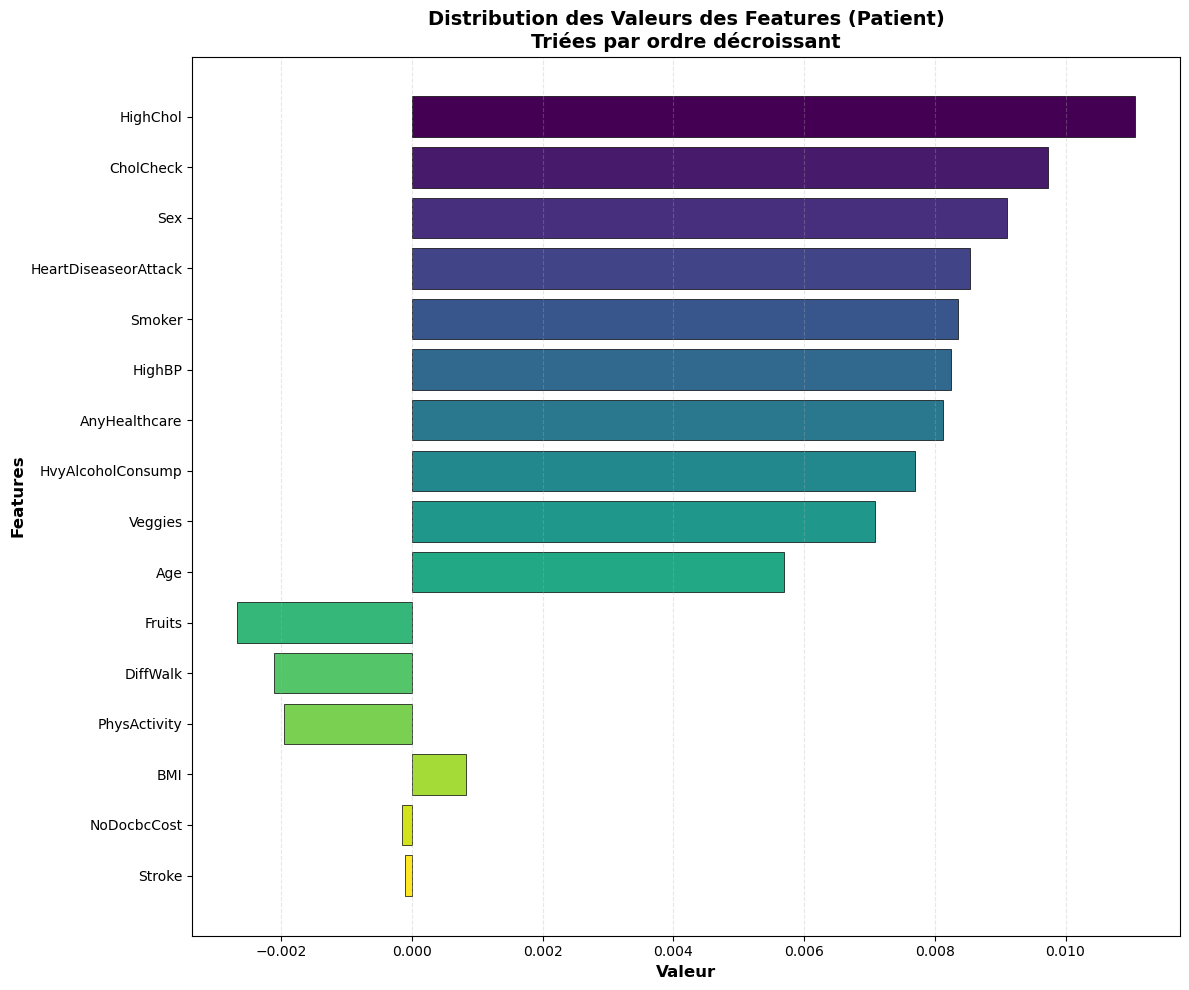

In [9]:
explainer_lime = LIME(nn)
explanation_lime = explainer_lime.explain(x_explain.reshape(1, -1))

features_df = pd.DataFrame({
    'Feature': X_validation.columns,
    'Valeur': explanation_lime
}).sort_values('Valeur', ascending=False, key=abs).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 10))

colors = plt.cm.viridis(np.linspace(0, 1, len(features_df)))
ax.barh(features_df['Feature'], features_df['Valeur'], color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Valeur', fontsize=12, fontweight='bold')
ax.set_ylabel('Features', fontsize=12, fontweight='bold')
ax.set_title('Distribution des Valeurs des Features (Patient)\nTriées par ordre décroissant', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')

ax.invert_yaxis()
plt.tight_layout()
plt.show()

Ce graphique représente l'importance locale des caractéristiques (features) pour un patient spécifique fait a partir de la technique d'explicabilité LIME

Il montre comment chaque facteur influence la prédiction du modèle vers le haut ou vers le bas.

**Analyse des facteurs aggravants (Positifs) :**\
Les facteurs en haut de la liste sont ceux qui pèsent le plus lourdement dans la décision du modèle pour ce patient :

- HighChol (Haut Cholestérol) : C'est le facteur le plus prépondérant (environ $+0.01$). Sa présence augmente significativement le risque prédit.
- CholCheck & Sex : Viennent ensuite le suivi du cholestérol et le sexe du patient, qui contribuent également de manière positive au score.
- Habitudes de vie : Le fait d'être fumeur (Smoker) et la consommation d'alcool (HvyAlcoholConsump) poussent également le curseur vers la droite.

**Analyse des facteurs protecteurs (Négatifs) :**\
Certaines caractéristiques agissent comme des "freins" au risque pour ce patient :

- DiffWalk (Difficulté à marcher) : Curieusement, ici cette valeur est négative. Dans ce contexte précis, cela signifie que la donnée associée à cette variable pour ce patient contribue à faire baisser la prédiction finale.
- PhysActivity & Fruits : La pratique d'une activité physique et la consommation de fruits ont un impact protecteur visible (valeurs autour de $-0.002$).

**Facteurs à impact faible :**\
BMI (IMC) & Stroke (AVC) : Leurs barres sont très courtes et proches de zéro. Pour ce patient précis, ces facteurs n'influencent quasiment pas le résultat du modèle, soit parce que les valeurs sont "normales", soit parce que le modèle ne les juge pas pertinentes dans ce cas particulier.

## SHAP (SHapley Additive exPlanations)

### Méthode SHAP basique

SHAP (SHapley Additive exPlanations) est une méthode d'explicabilité des modèles d'apprentissage automatique qui utilise les concepts de la théorie des jeux pour attribuer une importance à chaque caractéristique d'entrée dans la prédiction d'un modèle. SHAP calcule les valeurs de Shapley, qui représentent la contribution marginale de chaque caractéristique à la prédiction du modèle, en tenant compte de toutes les combinaisons possibles de caractéristiques.

Cette méthode fonctionne selon les étapes suivantes :

1. Pour chaque variable du jeu de données, on crée plusieurs sous-ensembles de variables qui la continennent.
2. On annule les variables non présentes dans le sous-ensemble en les remplaçant par la moyenne de leurs valeurs.
3. On calcule la prédiction du modèle sur le sous-ensemble, une fois avec la variable cible et une sans, et on calcule la différence entre les deux.
4. On pondère chacun des sous-ensemble en fonction du nombre de variables qu'il contient.
5. Finalement, la somme des différences des prédictions multipliées par leur poids permet d'obtenir la contribution de la variable cible à la prédiction.

**Création de sous-ensembles :**

Pour une variable cible $x$ (dont on veut calculer la contribution) de l'ensemble des variables du jeu de données $S$, on crée plusieurs sous-ensembles $s$ de variables qui la continennent, le nombre de sous-ensembles possibles est égale à $2^{|S|}$.

Ces sous ensembles sont ensuite copiés en deux exemplaires, un contenant la variable cible $x$, l'autre ne la contenant pas. 

On annule les variables non présentes dans le sous-ensemble en les remplaçant par la moyenne de leurs valeurs.

On pose donc :
- $S$ l'ensemble des variables
- $x$ la variable cible
- $s_{i_x}$ les $i$ sous-ensembles créés pour la variable $x$, qui la contiennent.
- $s_{i_{-x}}$ les $i$ sous-ensembles créés pour la variable $x$, qui ne la contiennent pas.


**Calcule des poids des sous-ensembles :**

On pondère chacun des sous-ensemble en fonction du nombre de variables qu'il contient. Le poids d'un sous-ensemble est calculé de la manière suivante :

$$w_{s_i}=\frac{|s_{i_{-x}}|!(|S|-|s_{i_{-x}}|-1)!}{|S|!}$$

**Calcule des contributions :**

La contribution de la variable $x$ est ensuite obtenue via la somme pondérée de ses contributions à la prédiction du modèle sur les sous-ensembles $s$.

On calcule la contribution de la variable $x$ sur un ensemble $s$ de la manière suivante :
$$\phi_{s_i}(x)=f(s_{i_{+x}})-f(s_{i_{-x}})$$
Où :
- $f(s)$ la prédiction du modèle sur l'ensemble $s$

La somme pondérée peut alors être écrite comme suit :

$$\phi(x)=\sum_{{s_i}\in S}{w_{s_i} \phi_{s_i}(x)}$$

**Retrouver la prédiciton originale :**

Une fois la contribution de chaque variable calculée, leur somme avec la valeur de base de prédiction du modèle.

La valeur de base est obtenue en calculant $f(\{\})$ c'est-à-dire la prédiction du modèle pour un ensemble vide de variables (toutes les variables sont remplacées par leur moyenne).

Ainsi :
$$\hat y \approx f(\{\}) + \sum \phi(x_j)$$

Où
- $\hat y$ est la prédiction du modèle
- $\phi(x_j)$ est la contribution pour la variable $x_j$ avec $j \in \big [0, |S| \big ]$ 

---
La version principale de SHAP nécessitant le calcul de toutes les combinaisons possibles de caractéristiques peut être très coûteuse en termes de temps de calcul, surtout pour les modèles avec un grand nombre de caractéristiques. Dans notre cas, nous avons 16 caractéristiques, ce qui signifie que nous devrions calculer les valeurs de Shapley pour $2^{16} = 65536$ combinaisons possibles de caractéristiques, ce qui est très coûteux en termes de temps de calcul. Pour cette raison, nous avons utilisé une version approximative de SHAP.

### Méthode KernelSHAP 

KernelSHAP est une version approximative de SHAP qui utilise un nombre fixe de combinaisons ($n$) de caratérstiques pour estimer les valeurs de Shapley, ce qui réduit considérablement le temps de calcul tout en fournissant des explications fiables.

Cette méthode fonctionne selon les étapes suivantes :
1. Création aléatoire de sous-ensemble de variables. Contrairement à la version basique de SHAP, les sous-ensembles ne dépendent pas d'une caractéristique particulière.\
   Par rapport à la méthode précédente, on redéfinit donc :
     - $s_i$ les $i$ sous-ensembles.
2. Détermination des poids de chaque sous-ensemble selon une nouvelle formule :
   $$w_{s_i} = \frac{|S|-1}{\binom{|S|}{|s_i|} |s_i| (|S| - |s_i|)}$$
3. Application des combinaisons (sous-ensembles) sur l'échantillon sélectionné au départ. On remplace les données de l'échantillon qui ne sont pas dans la combinaison par une moyenne de nos données de *background*, ainsi on rend ces valeurs non pertinentes. À l'issue de cette étape, on a donc une liste de $n$ échantillons pour les $n$ sous-ensembles.
4. Prédiction du modèle pour chaque échantillons, donc pour chaque sous-ensembles.
5. Application d'une régression linéaire en utilisant, par exemple, la méthode des moindres carrés afin de déterminer les contributions marginales de chaque variables à partir des données précédement générées. Appliquer cette méthode suggère que l'on considère l'équation suivante :
   $$\hat y_{s_i} = f(\{\}) + \sum^n_{i=0} \phi_{s_i} * w_{s_i}$$
   Où seul les contributions $\phi_{s_i}$ sont inconnus, les prédictions $\hat y_{s_i}$, la valeur de base $f(\{\})$ (la valeur est calculée comme dans la méthode précédente en utilisant la prédiction du modèle sur un échantillon moyen des données du *background*) et les poids $w_{s_i}$ ont été déterminés plus tôt.

Après la régression, on obtient donc une liste de contributions comme avec la méthode basique de SHAP sans avoir à calculer l'ensemble des combinaisons.

In [10]:
explainer_shap = SHAP(model=nn, background_data=X_validation.to_numpy()[:100], feature_names=X_validation.columns, num_samples=100)

explainatinations, base_value = explainer_shap.explain(x_explain)

In [11]:
prediction  = nn.predict_proba(x_explain.reshape(1, -1))

explainer_shap.print_stats(x_explain, explainatinations, base_value, model_predictions=prediction.flatten())

Base value: 0.5675
Sum of SHAP values: 0.0450
Model prediction: 0.6162
Sum of SHAP value and base value: 0.6125
                 Feature  SHAP Value
0                 HighBP    0.069796
1               HighChol    0.032676
2              CholCheck   -0.001756
3                    BMI    0.011340
4                 Smoker    0.001773
5                 Stroke   -0.013319
6   HeartDiseaseorAttack    0.066644
7           PhysActivity    0.034346
8                 Fruits    0.018731
9                Veggies   -0.007149
10     HvyAlcoholConsump   -0.170089
11         AnyHealthcare   -0.006715
12           NoDocbcCost   -0.002944
13              DiffWalk   -0.044316
14                   Sex    0.053749
15                   Age    0.002209


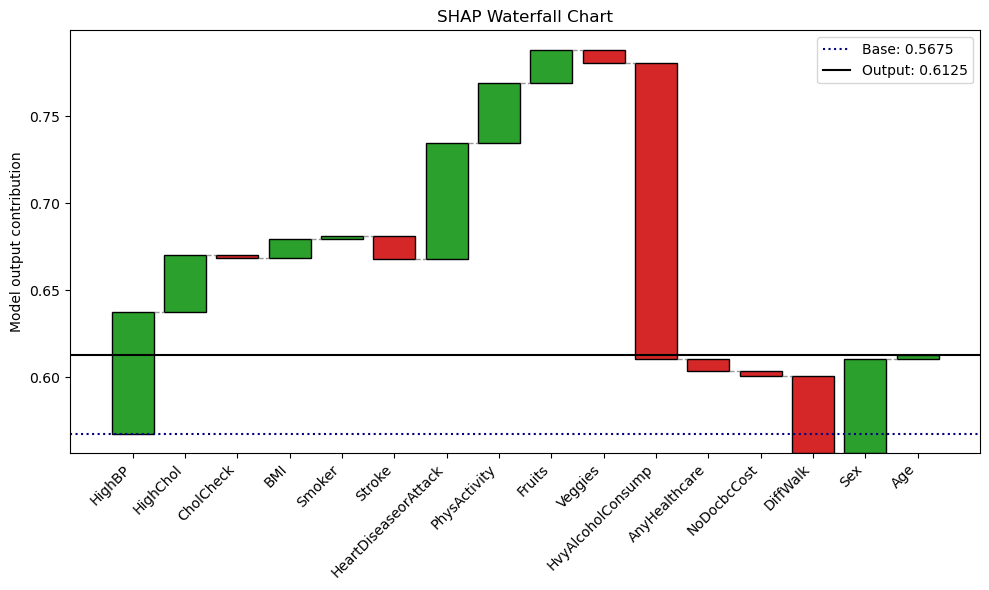

In [12]:
explainer_shap.waterfall(explainatinations, base_value)

La figure ci-dessus est un graphique en cascade de SHAP, nous l'utilisons pour expliquer pourquoi un modèle a pris une décision spécifique pour un individu donné.

Nous pouvons distingué 2 couleurs :
- Vert : Ces variables augmentent la probabilité du résultat (elles poussent le score vers le haut).
- Rouges : Ces variables diminuent la probabilité du résultat (elles poussent le score vers le bas).

Les facteurs aggravants qui poussent vers 1, donc qui augmente la probabilité qu'a le patient d'être diabétique :
- `HeartDiseaseorAttack` : C'est la variable qui a l'impact positif le plus massif.
- `HighBP` : Cette variable contribue fortement à augmenter le score de risque.
- `HighChol` & `Sex` : Augmente également significativement le risque.

Et les facteurs qui poussent vers le bas, vers 0, qui diminue la probabilité qu'a le patient de ne pas être diabétique :
- `HvyAlcoholConsump` : Nous pouvons voir que cette variable réduit fortement la prédiction finale. 
- `DiffWalk` : Réduit également le score.

Nous pouvons aussi voir des variable à faible contribution comme `Age`, `Stroke`, `Smoker` et `NoDocbcCost`. Dont les valeurs sont proches de 0 et ont donc pas beaucoup d'influence sur la prédiction finale.

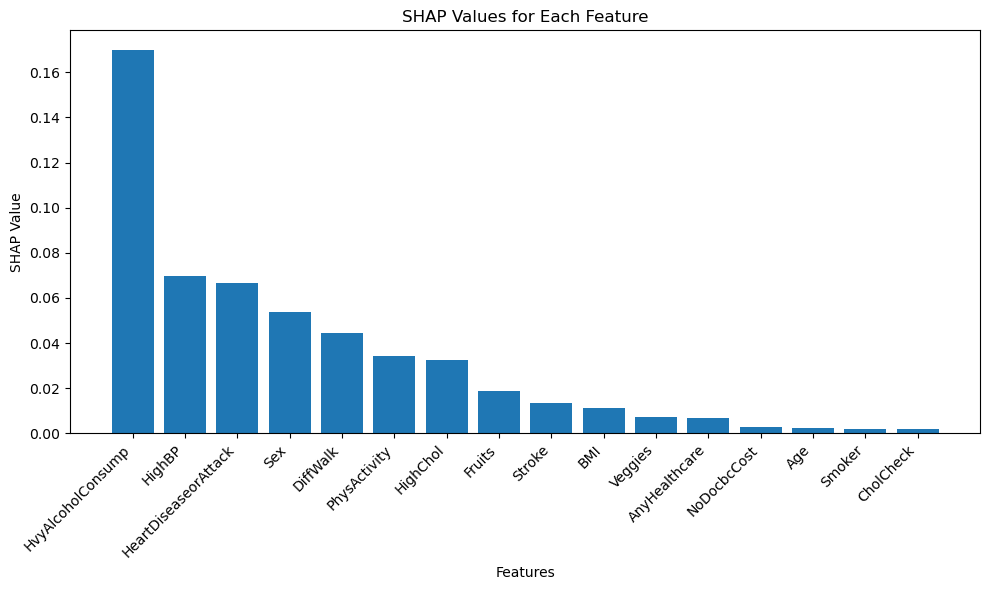

In [13]:
explainer_shap.histogram(explainatinations)

## Comparaison et Conclusion

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,Age
LIME,0.008253,0.011064,0.009735,0.000834,0.008352,-0.000103,0.008545,-0.001954,-0.002670,0.007079,0.007693,0.008120,-0.000144,-0.002103,0.009108,0.005698
SHAP,0.069796,0.032676,-0.001756,0.011340,0.001773,-0.013319,0.066644,0.034346,0.018731,-0.007149,-0.170089,-0.006715,-0.002944,-0.044316,0.053749,0.002209


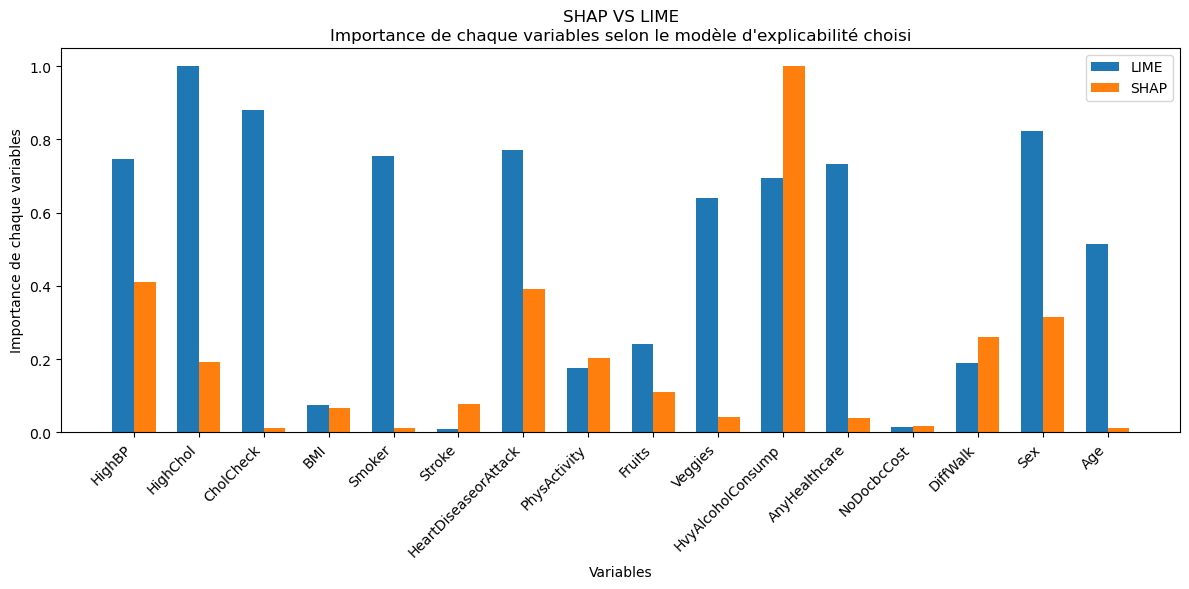

In [91]:
display(pd.DataFrame({
    "LIME": explanation_lime,
    "SHAP": explainatinations.flatten()
}).set_index([pd.Index(list(X_validation.columns))]).T)

x = np.arange(len(X_validation.columns))
fig = plt.figure(figsize=(12, 6))
plt.bar(x, np.abs(explanation_lime) / max(np.abs(explanation_lime)), 1/3, label="LIME")
plt.bar(x + 1/3, np.abs(explainatinations.flatten()) / max(np.abs(explainatinations.flatten())), 1/3, label="SHAP")
plt.xlabel("Variables")
plt.ylabel("Importance de chaque variables")
plt.title("SHAP VS LIME\nImportance de chaque variables selon le modèle d'explicabilité choisi")
plt.xticks(x + 1/6, X_validation.columns, rotation=45, ha='right')
plt.tight_layout()
plt.legend()
plt.show()

Dans le cas sélectionné, les explications fournies par LIME et SHAP ne permettent pas de conclure quant à l'importance d'une ou plusieurs variables sur la prédiction finale. On peut cependant, noter quelques variables qui semblent sortir du lot :
- HvyAlcoholConsump : Une forte une consommation d'alcool
- HeartDiseaseorAttack : Présence d'une maladie/crise cardiaque dans le dossier médicale 
- HighBP : Pression sanguine élevée

Si on en crois plusieurs sources (comme le livre *Interpretable Machine Learning* de Christoph Molnar), la méthode SHAP serait plus fiable que la méthode LIME donc pour une future explication d'une prédiction de notre modèle, nous préfererons utiliser la méthode SHAP.

# Consommation et emissions

La consommation énergétique d'un modèle d'IA provient principalement de l'entraînement du modèle, qui nécessite des calculs intensifs sur des données volumineuses. Les modèles de Deep Learning, en particulier, peuvent nécessiter des ressources informatiques considérables, ce qui se traduit par une consommation énergétique élevée. De plus, l'infrastructure utilisée pour héberger et exécuter les modèles d'IA, comme les centres de données, peut également contribuer à la consommation énergétique globale.

Plusieurs facteurs peuvent influencer la consommation énergétique d'un modèle d'IA, notamment :
- La taille du modèle : Les modèles plus grands avec plus de paramètres nécessitent généralement plus de ressources pour l'entraînement, ce qui peut augmenter la consommation énergétique.
- La quantité de données : L'entraînement sur de grandes quantités de données peut nécessiter plus de temps de calcul, ce qui peut également augmenter la consommation énergétique.
- Le type de matériel : L'utilisation de GPU ou de TPU peut accélérer l'entraînement, mais peut également consommer plus d'énergie que les CPU traditionnels.
- La durée de l'entraînement : Plus le modèle est entraîné longtemps, plus la consommation énergétique peut être élevée.
- La production d'énergie du pays : L'intensité carbone de l'électricité utilisée pour alimenter les centres de données peut varier considérablement d'un pays à l'autre, ce qui peut influencer l'empreinte carbone associée à l'entraînement d'un modèle d'IA.

Estimer la consommation énergétique d’un modèle d’IA est un processus complexe qui dépend de plusieurs facteurs (sités ci-dessus). Cependant, il existe des méthodes simplifiées pour estimer cette consommation énergétique :

$$
CO_2e = (E_{CPU} + E_{GPU} + E_{RAM}) \times \text{PUE} \times \text{CI}
$$

Où :
- $E_{CPU}$ : Énergie consommée par le CPU (en $kWh$)
- $E_{GPU}$ : Énergie consommée par le GPU (en $kWh$)
- $E_{RAM}$ : Énergie consommée par la RAM (en $kWh$)
- $PUE$ (Power Usage Effectiveness) : Efficacité énergétique de l'appareil ou du centre de données (généralement compris entre $1.0$ et $2.0$). On considère souvent une valeur de $1.0$ pour les ordinateurs personnels et une valeur de $1.5$ à $2.0$ pour les centres de données.
- $CI$ (Carbon Intensity) : Intensité carbone de l'électricité utilisée (en $kg\ CO_2e/kWh$). Concrètement, cela dépend du mix énergétique du pays où l'entraînement a lieu. Par exemple, un pays utilisant principalement des énergies renouvelables aura une intensité carbone plus faible que celui utilisant principalement des énergies fossiles. En France, l'intensité carbone est d'environ $0.05\ kg\ CO_2e/kWh$, tandis qu'aux États-Unis, elle est d'environ $0.45\ kg\ CO_2e/kWh$.

Par exemple pour un modèle entraîné pendant $10$ heures sur un appareil comme celui faisant tourner ce notebook :
- CPU : AMD Ryzen 7 2700X Eight-Core Processor consommant environ $35\ W$
- RAM : 2x16 GB DDR4 consommant environ $12\ W$
- PUE : $1.0$ (Appareil personnel)
- CI : $0.05\ kg\ CO_2e/kWh$ (France)

$$
\begin{array}{rll}
	E_{CPU} &=& 35\ W \times 10\ h = 350\ Wh = 0.35\ kWh \\
	E_{RAM} &=& 12\ W \times 10\ h = 120\ Wh = 0.12\ kWh \\
	CO_2e &=& (0.35 + 0.12) \times 1.0 \times 0.05 \\
		  &=& 0.47 \times 0.05 \\
		  &=& 0.0235\ kg\ CO_2e
\end{array}
$$

Nous avons utilisé la bibliothèque *CodeCarbon* pour mesurer la consommation d'énergie et les émissions de carbone associées à l'entraînement de nos modèles. Nous avons comparé les résultats obtenus avec un taux d'apprentissage fixe et un taux d'apprentissage adaptatif pour évaluer l'impact de ces approches sur la consommation d'énergie et les émissions de carbone.

In [88]:
nnn_adaptive_lr = NeuralNetwork([
    Layer(neurons=64, activation=Relu(), dropout_rate=0.2),
    Layer(neurons=32, activation=Relu(), dropout_rate=0.2),
    Layer(neurons=1, activation=Sigmoid(), dropout_rate=0.0),
], loss=BinaryCrossEntropy(), inputs=X_train.shape[1])

carbon_adaptive_lr = CarbonEmissions()

nnn_adaptive_lr.add_callback(EarlyStopping(patience=10))
nnn_adaptive_lr.add_callback(ReduceOnPlateau(initial_lr=0.1))
nnn_adaptive_lr.add_callback(TrainProgressBar())
nnn_adaptive_lr.add_callback(carbon_adaptive_lr)

nnn_adaptive_lr.fit(
    X_train.to_numpy(),
    y_train.to_numpy(),
    epochs=500,
    batch_size=500,
    learning_rate=0.1
)

nnn_fixed_lr = NeuralNetwork([
    Layer(neurons=64, activation=Relu(), dropout_rate=0.2),
    Layer(neurons=32, activation=Relu(), dropout_rate=0.2),
    Layer(neurons=1, activation=Sigmoid(), dropout_rate=0.0),
], loss=BinaryCrossEntropy(), inputs=X_train.shape[1])

carbon_fixed_lr = CarbonEmissions()
nnn_fixed_lr.add_callback(EarlyStopping(patience=10))
nnn_fixed_lr.add_callback(TrainProgressBar())
nnn_fixed_lr.add_callback(carbon_fixed_lr)

nnn_fixed_lr.fit(
    X_train.to_numpy(),
    y_train.to_numpy(),
    epochs=500,
    batch_size=500,
    learning_rate=0.1
)

[codecarbon WARNING @ 00:44:20] Multiple instances of codecarbon are allowed to run at the same time.


Training NeuralNetwork:   0%|          | 0/500 [00:00<?, ?epoch/s]

Training NeuralNetwork:   0%|          | 0/500 [00:00<?, ?epoch/s]

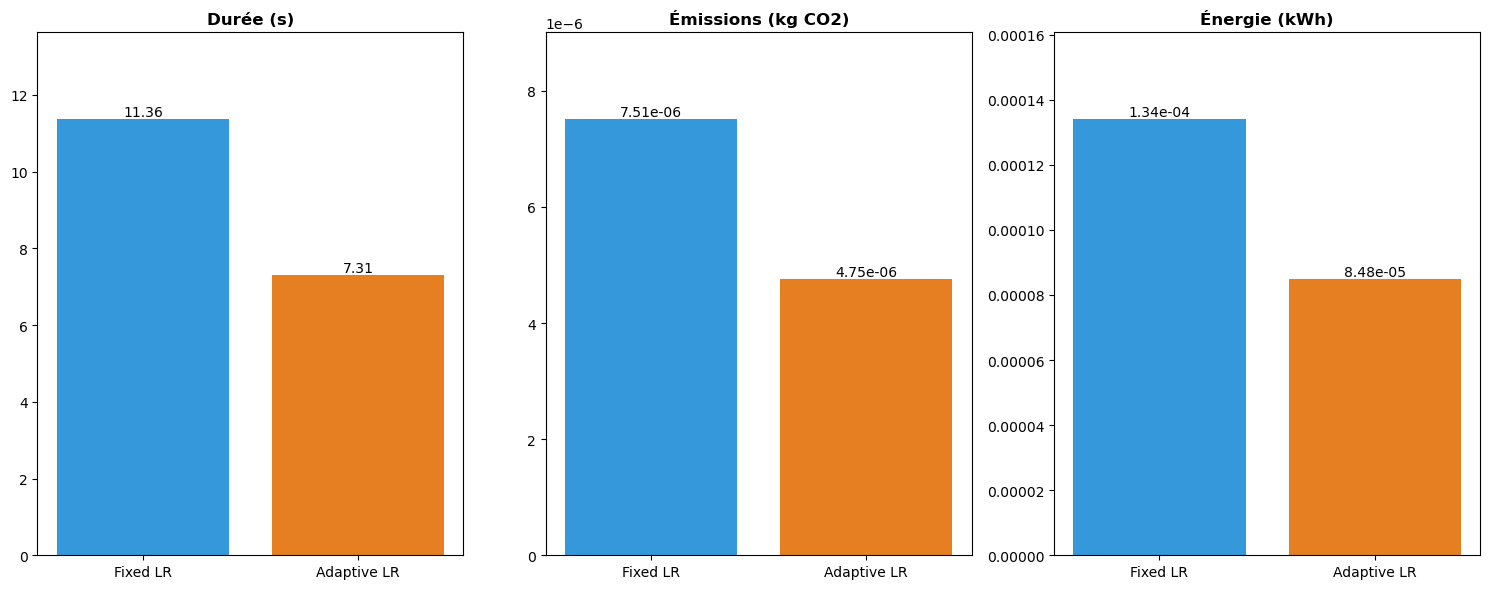

In [89]:
emssions_fixed_lr = carbon_fixed_lr.get_result()
emssions_adaptive_lr = carbon_adaptive_lr.get_result()

metrics_to_plot = ['duration', 'emissions', 'energy_consumed']
titles = ['Durée (s)', 'Émissions (kg CO2)', 'Énergie (kWh)']

data_fixed = [emssions_fixed_lr.iloc[0][m] for m in metrics_to_plot]
data_adaptive = [emssions_adaptive_lr.iloc[0][m] for m in metrics_to_plot]

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
labels = ['Fixed LR', 'Adaptive LR']
colors = ['#3498db', '#e67e22']

for i in range(3):
    values = [data_fixed[i], data_adaptive[i]]
    bars = axes[i].bar(labels, values, color=colors)
    
    axes[i].set_title(titles[i], fontweight='bold')
    
    axes[i].set_ylim(0, max(values) * 1.2)
    
    for bar in bars:
        height = bar.get_height()
        label_text = f"{height:.2e}" if height < 0.01 else f"{height:.2f}"
        axes[i].text(bar.get_x() + bar.get_width()/2., height,
                     label_text, ha='center', va='bottom')

plt.tight_layout()
plt.show()

Nous pouvons constater que le modèle avec un taux d'apprentissage adaptatif (Adaptive LR) a consommé nettement moins d'énergie et émis moins de carbone que le modèle avec un taux d'apprentissage fixe (Fixed LR).

Cette performance supérieure s'explique par les points suivants :

- **Réduction du temps de calcul :** Le modèle avec un taux d'apprentissage adaptatif s'est arrêté environ deux fois plus vite, avec une durée de 10,18 s contre 19,29 s pour le modèle fixe. Cette convergence accélérée est le levier principal de l'économie réalisée.

- **Impact environnemental :** En conséquence, les émissions de CO2 ont été réduites de près de moitié, passant de 1,26e-05 kg à seulement 6,77e-06 kg.

- **Efficacité énergétique :** La consommation électrique suit la même tendance, avec une baisse significative de 2,25e-04 kWh à 1,21e-04 kWh.

L'utilisation d'un optimiseur à taux d'apprentissage adaptatif permet non seulement d'optimiser les ressources de calcul, mais s'inscrit également dans une démarche de "Green AI" en minimisant l'empreinte carbone directe de la phase d'entraînement.

# Résumé et Conclusions
